In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [130]:
weights = np.array([20, 40, -300])
house = np.array([[2000, 3, 20],
                  [1500, 4, 30]])

y_hat_non_vec_h1 = weights[0] * house[0, 0] + weights[1] * house[0, 1] + weights[2] * house[0, 2] + 2000
y_hat_non_vec_h2 = weights[0] * house[1, 0] + weights[1] * house[1, 1] + weights[2] * house[1, 2] + 2000

print(y_hat_non_vec_h1)
print(y_hat_non_vec_h2)

36120
23160


In [131]:
y_hat_vec = house @ weights + 2000
y_hat_vec

array([36120, 23160])

In [132]:
df = pd.read_csv(r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-06-regression-and-classification-ML\datasets\kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [133]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [134]:
df.drop(columns=["id", 'date'], inplace=True)

In [135]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [136]:
df.corr()['price'].sort_values(ascending=False).round(3).drop('price')

sqft_living      0.702
grade            0.667
sqft_above       0.606
sqft_living15    0.585
bathrooms        0.525
view             0.397
sqft_basement    0.324
bedrooms         0.308
lat              0.307
waterfront       0.266
floors           0.257
yr_renovated     0.126
sqft_lot         0.090
sqft_lot15       0.082
yr_built         0.054
condition        0.036
long             0.022
zipcode         -0.053
Name: price, dtype: float64

In [137]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [150]:
features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors',
       'waterfront', 'view', 'grade', 'sqft_above',
       'sqft_basement', 'lat', 
       'sqft_living15']


X = df[features].values

In [151]:
y = df['price'].values

In [152]:
X.shape

(21613, 11)

In [153]:
y.shape

(21613,)

In [154]:
X_max = X.max(axis=0)

In [155]:
X_max

array([3.30000e+01, 8.00000e+00, 1.35400e+04, 3.50000e+00, 1.00000e+00,
       4.00000e+00, 1.30000e+01, 9.41000e+03, 4.82000e+03, 4.77776e+01,
       6.21000e+03])

In [156]:
# X_scaled = X/X_max

xmean = X.mean(axis=0)
xstd = X.std(axis=0)

X_scaled = (X - xmean)/xstd

ymean, ystd = y.mean(), y.std()
y_scaled = (y - ymean)/ystd

print(np.round(X_scaled.mean(axis=0), 3))
print(np.round(X_scaled.std(axis=0), 3))

[ 0. -0.  0. -0. -0. -0.  0.  0.  0. -0.  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [146]:
X_scaled.shape

(21613, 11)

In [147]:
y_scaled = y/y.max()

In [148]:
y_scaled.min()

0.00974025974025974

In [157]:
def predict(X, w, b):
    return X @ w + b

In [21]:
def cost(X, y, w, b):
    y_hat = predict(X, w, b)
    error = y_hat - y
    return np.mean(error**2)/2

In [22]:
def gradient(X, y, w, b):
    y_hat = predict(X, w, b)
    error = y_hat - y
    gw = (X.T @ error)/len(y)
    gb = np.mean(error)

    return gw, gb

In [23]:
n_features = X_scaled.shape[1]
w = np.zeros(n_features)
b = 0
learning_rate = 0.1
history = []


for i in range(1, 1001):
    gw, gb = gradient(X_scaled, y_scaled, w, b)
    w = w - learning_rate * gw
    b = b - learning_rate * gb
    history.append(cost(X_scaled, y_scaled, w, b))

    print(f"Epoch : {i} | cost : {cost(X_scaled, y_scaled, w, b)}")

Epoch : 1 | cost : 0.0023534889849969164
Epoch : 2 | cost : 0.0017039194504708509
Epoch : 3 | cost : 0.0013636780010176021
Epoch : 4 | cost : 0.0011846820129062198
Epoch : 5 | cost : 0.0010897456257241396
Epoch : 6 | cost : 0.0010386368097660547
Epoch : 7 | cost : 0.001010385142909577
Epoch : 8 | cost : 0.000994060015822513
Epoch : 9 | cost : 0.0009839639155505614
Epoch : 10 | cost : 0.0009771269997059494
Epoch : 11 | cost : 0.0009720011824141365
Epoch : 12 | cost : 0.000967779447016859
Epoch : 13 | cost : 0.0009640410484500693
Epoch : 14 | cost : 0.0009605665805215277
Epoch : 15 | cost : 0.0009572415826125174
Epoch : 16 | cost : 0.0009540062961706255
Epoch : 17 | cost : 0.000950829476059886
Epoch : 18 | cost : 0.0009476947401294213
Epoch : 19 | cost : 0.0009445934541325683
Epoch : 20 | cost : 0.00094152102309536
Epoch : 21 | cost : 0.000938474958243553
Epoch : 22 | cost : 0.0009354538694118515
Epoch : 23 | cost : 0.0009324569398463181
Epoch : 24 | cost : 0.000929483652446753
Epoch : 2

In [24]:
cost(X_scaled, y_scaled, w, b)

0.0005011261676288978

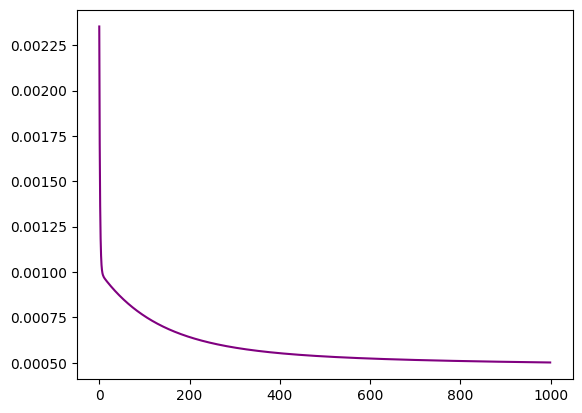

In [25]:
plt.plot(history, color="purple")

In [26]:
for name, weight in zip(features, w):
    print(f"{name:12s}: {weight:+.3f}")

bedrooms    : +0.005
bathrooms   : +0.046
sqft_living : +0.067
floors      : +0.009
waterfront  : +0.040
view        : +0.051
grade       : +0.080
sqft_above  : +0.069
sqft_basement: +0.053
lat         : -0.020
sqft_living15: +0.067


In [27]:
prediction = predict(X_scaled, w, b)

In [28]:
prediction.shape

(21613,)

In [29]:
y_scaled.shape

(21613,)

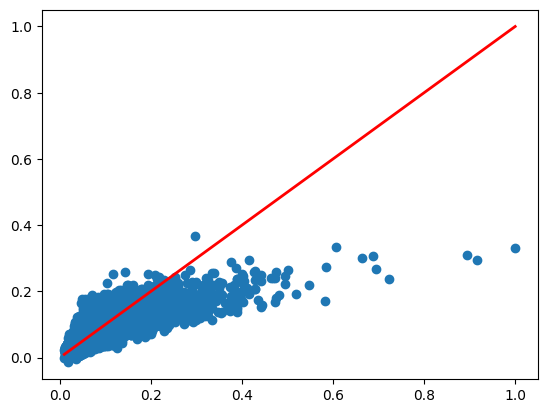

In [30]:
plt.scatter(y_scaled, prediction)
lims = [y_scaled.min(), y_scaled.max()]
plt.plot(lims, lims, color='red', linewidth=2, label="perfect prediction")

In [31]:
y_scaled.min(), y_scaled.max()

(0.00974025974025974, 1.0)

In [32]:
prediction

array([0.03621849, 0.06802137, 0.03968701, ..., 0.03164075, 0.05927968,
       0.03164087])

In [33]:
y_scaled

array([0.02881818, 0.06987013, 0.02337662, ..., 0.05222091, 0.05194805,
       0.04220779])

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [158]:
X_scaled.shape

(21613, 11)

In [159]:
y_scaled.shape

(21613,)

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))

17290
4323


In [161]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [162]:
predictions = model.predict(X_test)

In [163]:
r2 = r2_score(y_test, predictions)
r2

0.6614781405487573

In [164]:
np.sqrt(mean_squared_error(y_test, predictions))

0.6162107867953159

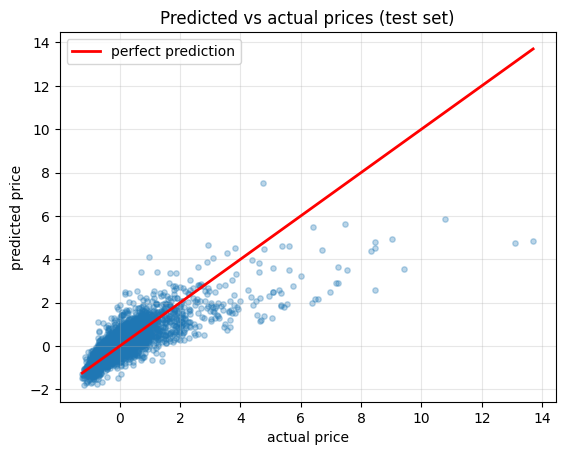

In [165]:
plt.scatter(y_test, predictions, alpha=0.3, s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color='red', linewidth=2, label="perfect prediction")
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("Predicted vs actual prices (test set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [166]:
coefficients = pd.DataFrame({'features':features, 'coefficient':model.coef_})

In [167]:
coefficients.sort_values('coefficient', ascending=False)

,features,coefficient
6,grade,0.256226
9,lat,0.253341
2,sqft_living,0.247225
7,sqft_above,0.213978
5,view,0.143131
4,waterfront,0.137773
8,sqft_basement,0.112676
10,sqft_living15,0.006264
1,bathrooms,-0.001104
3,floors,-0.045001


In [168]:
y_test

array([-0.47692515,  0.88503216,  1.35626939, ..., -0.69483832,
        0.17681436, -0.50007842])

In [169]:
X_test[0]

array([ 0.67648506,  0.1756067 , -0.0107791 ,  0.93650577, -0.08717263,
       -0.30575946,  0.29191561,  0.34007836, -0.65868104, -0.87508717,
        0.58865183])

In [170]:
coefficients

,features,coefficient
0,bedrooms,-0.060626
1,bathrooms,-0.001104
2,sqft_living,0.247225
3,floors,-0.045001
4,waterfront,0.137773
5,view,0.143131
6,grade,0.256226
7,sqft_above,0.213978
8,sqft_basement,0.112676
9,lat,0.253341


In [171]:
cof = model.coef_

In [172]:
model.intercept_

-0.0019242375128458713

In [173]:
cof[0]

-0.06062582399850516

In [174]:
cof

array([-0.06062582, -0.00110364,  0.24722475, -0.04500098,  0.13777254,
        0.14313104,  0.25622631,  0.21397849,  0.11267618,  0.25334058,
        0.00626356])

In [179]:
np.sum(X_test[0] * cof) - 0.0019242375128458713

-0.28837249407736176

In [180]:
(X_test[0, 0] * cof[0]) + (X_test[0, 1] * cof[1]) + (X_test[0, 2] * cof[2]) + (X_test[0, 3] * cof[3]) + (X_test[0, 4] * cof[4]) + (X_test[0, 5] * cof[5]) + (X_test[0, 6] * cof[6]) + (X_test[0, 7] * cof[7]) + (X_test[0, 8] * cof[8]) + (X_test[0, 9] * cof[9]) + (X_test[0, 10] * cof[10]) -0.0019242375128458713

-0.28837249407736176

In [177]:
model.predict(X_test[0].reshape(1, 11))

array([-0.28837249])

In [178]:
predictions

array([-0.28837249,  0.60042735,  1.87776498, ..., -0.37310163,
        0.16801465, -0.31327029])

In [109]:
y.max()

7700000.0

In [124]:
y_test

array([ 365000.,  865000., 1038000., ...,  285000.,  605000.,  356500.])

In [128]:
np.sqrt(np.mean((y_test - predictions)**2))

226222.50493467212